In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv ('/PyAi/datakecukupanpangan.csv')

In [4]:
df.head(5)

,No,Tahun,Kode_Provinsi,Provinsi,PoU,Jumlah_Penduduk,Penduduk_Undernourish
0,1,2018,11,ACEH,8.66,5243400,454185
1,2,2018,12,SUMATERA UTARA,5.73,14476000,829915
2,3,2018,13,SUMATERA BARAT,5.45,5411800,294684
3,4,2018,14,RIAU,9.63,6717600,646660
4,5,2018,15,JAMBI,10.04,3527100,354285


In [5]:
# 1. Tulis jumlah baris dan jumlah kolom
df.shape

(242, 7)

In [6]:
# Tulis daftar nama kolom.
df.columns.tolist()

['No',
 'Tahun',
 'Kode_Provinsi',
 'Provinsi',
 'PoU',
 'Jumlah_Penduduk',
 'Penduduk_Undernourish']

In [10]:
#3. Cek rentang tahun: tahun paling kecil dan paling besar.
df['Tahun'].min(), df['Tahun'].max()

(np.int64(2018), np.int64(2024))

In [11]:
#4. Cek jumlah provinsi per tahun: “di 2018 ada berapa provinsi? di 2024 ada berapa provinsi?
df.groupby('Tahun')['Provinsi'].nunique()

Tahun
2018    34
2019    34
2020    34
2021    34
2022    34
2023    34
2024    38
Name: Provinsi, dtype: int64

In [17]:
#5. ) Cek missing value per kolom(ada/tidak + jumlahnya).
df.isnull().sum()

No                       0
Tahun                    0
Kode_Provinsi            0
Provinsi                 0
PoU                      0
Jumlah_Penduduk          0
Penduduk_Undernourish    0
dtype: int64

In [12]:
#6.  Cek apakah ada baris duplikat (minimal cek duplikat kombinasiTahun+Provinsi
df.duplicated(subset=['Tahun', 'Provinsi']).sum()

np.int64(0)

In [46]:
# 7. Cek nilai tidak masuk akal:
df['PoU'] < 0

0      False
1      False
2      False
3      False
4      False
       ...  
237    False
238    False
239    False
240    False
241    False
Name: PoU, Length: 242, dtype: bool

In [47]:
df['PoU'] > 100

0      False
1      False
2      False
3      False
4      False
       ...  
237    False
238    False
239    False
240    False
241    False
Name: PoU, Length: 242, dtype: bool

In [15]:
(df['Penduduk_Undernourish'] > df['Jumlah_Penduduk'])

0      False
1      False
2      False
3      False
4      False
       ...  
237     True
238     True
239     True
240     True
241     True
Length: 242, dtype: bool

In [16]:
#8. kolom baru
df['Rate_Undernourish'] = (
    df['Penduduk_Undernourish'] / df['Jumlah_Penduduk']
) * 100

df[['PoU', 'Rate_Undernourish']].head()

,PoU,Rate_Undernourish
0,8.66,8.662032
1,5.73,5.733041
2,5.45,5.445212
3,9.63,9.626355
4,10.04,10.044654


In [17]:
#9
df['Selisih'] = df['Rate_Undernourish'] - df['PoU']

In [19]:
#9
df.loc[
    df['Selisih'].abs().sort_values(ascending=False).head(5).index,
    ['Tahun', 'Provinsi', 'PoU', 'Rate_Undernourish', 'Selisih']
]

,Tahun,Provinsi,PoU,Rate_Undernourish,Selisih
239,2024,PAPUA TENGAH,37.69,3768.999989,3731.309989
234,2024,MALUKU,31.66,3166.000018,3134.340018
238,2024,PAPUA SELATAN,29.26,2926.000083,2896.740083
235,2024,MALUKU UTARA,28.44,2844.000009,2815.560009
240,2024,PAPUA PEGUNUNGAN,27.26,2726.000031,2698.740031


In [20]:
#10
tahun_terbaru = df['Tahun'].max()
tahun_terbaru

np.int64(2024)

In [22]:
#10 top 5 tertinggi
df[df['Tahun'] == tahun_terbaru] \
  .sort_values('PoU', ascending=False) \
  .head(5)[['Provinsi', 'PoU']]

,Provinsi,PoU
239,PAPUA TENGAH,37.69
234,MALUKU,31.66
238,PAPUA SELATAN,29.26
235,MALUKU UTARA,28.44
240,PAPUA PEGUNUNGAN,27.26


In [23]:
#10 top 5 terendah
df[df['Tahun'] == tahun_terbaru] \
  .sort_values('PoU') \
  .head(5)[['Provinsi', 'PoU']]


,Provinsi,PoU
219,BANTEN,2.55
221,NUSA TENGGARA BARAT,2.74
220,BALI,3.20
214,DKI JAKARTA,3.53
225,KALIMANTAN SELATAN,3.83


In [24]:
#rata-rata
rata_pou_tahun = df.groupby('Tahun')['PoU'].mean().reset_index()
rata_pou_tahun

,Tahun,PoU
0,2018,10.696765
1,2019,10.306176
2,2020,11.017941
3,2021,11.324412
4,2022,13.676765
5,2023,11.488235
6,2024,12.640789


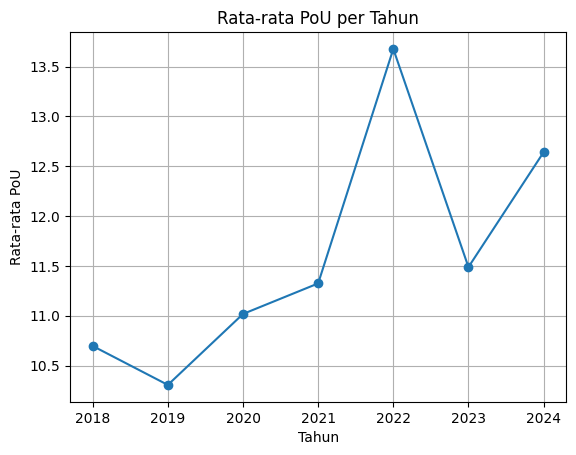

In [25]:
#12. VISUALISASI
plt.figure()
plt.plot(rata_pou_tahun['Tahun'], rata_pou_tahun['PoU'], marker='o')
plt.xlabel("Tahun")
plt.ylabel("Rata-rata PoU")
plt.title("Rata-rata PoU per Tahun")
plt.grid(True)
plt.show()

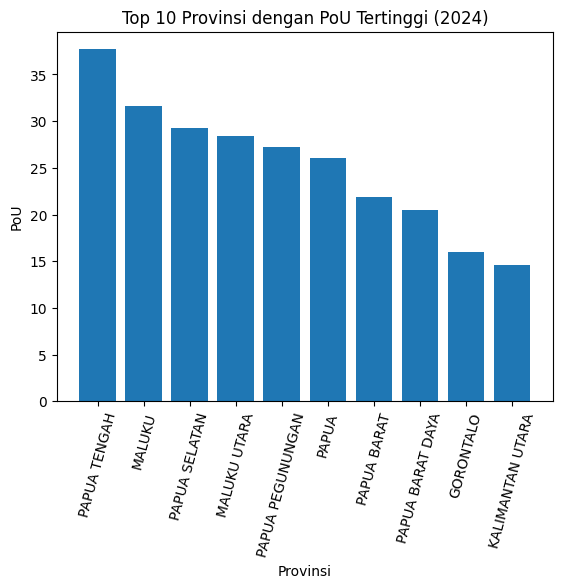

In [27]:
#13. barchart
top10 = df[df['Tahun'] == tahun_terbaru] \
        .sort_values('PoU', ascending=False) \
        .head(10)

plt.figure()
plt.bar(top10['Provinsi'], top10['PoU'])
plt.xticks(rotation=75)
plt.xlabel("Provinsi")
plt.ylabel("PoU")
plt.title(f"Top 10 Provinsi dengan PoU Tertinggi ({tahun_terbaru})")
plt.show()

In [ ]:
#F. 
tren
rata-rata nilai Prevalence of Undernourishment (PoU) per tahun menunjukkan pola fluktuatif, dengan peningkatan pada tahun 2022 dan penurunan pada tahun-tahun berikutnya

wilayah
provinsi-provinsi di wilayah Papua dan pemekarannya memiliki nilai PoU tertinggi, sedangkan Provinsi Banten, Bali, dan DKI Jakarta memiliki nilai PoU terendah

perbandingan PoU dan Rate_Undernourish
nilai PoU dan Rate_Undernourish menunjukkan kecenderungan yang searah, namun tidak selalu sama karena perbedaan metode perhitungan, yaitu estimasi survei dan perhitungan langsung berdasarkan jumlah penduduk